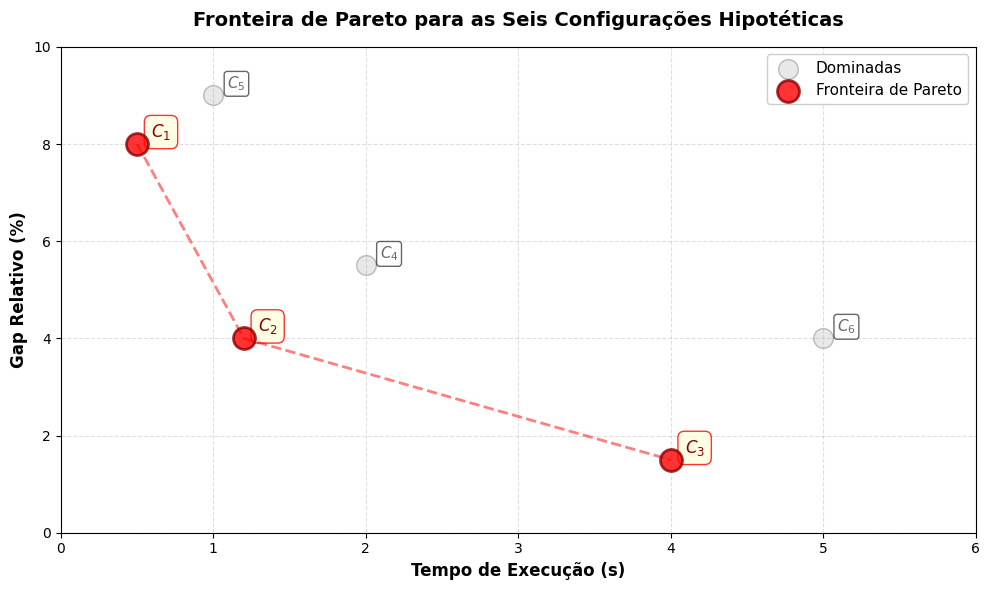


FRONTEIRA DE PARETO - TABELA HIPOTÉTICA

Configurações Eficientes (Fronteira de Pareto):
 id  gap  tempo
C_1  8.0    0.5
C_2  4.0    1.2
C_3  1.5    4.0


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# DADOS DA TABELA HIPOTÉTICA DO TCC
# ---------------------------------------------------------
data = {
    "id": ["C_1", "C_2", "C_3", "C_4", "C_5", "C_6"],
    "gap": [8.0, 4.0, 1.5, 5.5, 9.0, 4.0],
    "tempo": [0.5, 1.2, 4.0, 2.0, 1.0, 5.0]
}
df_hipotetico = pd.DataFrame(data)

# ---------------------------------------------------------
# CÁLCULO DA FRONTEIRA DE PARETO
# Objetivos: Minimizar Gap (%) e Tempo (s)
# ---------------------------------------------------------
def calcular_pareto(df, col_x, col_y):
    """
    Calcula a fronteira de Pareto para minimizar col_x e col_y
    Retorna índices dos pontos na fronteira
    """
    pareto_indices = []
    for i, row_i in df.iterrows():
        dominado = False
        for j, row_j in df.iterrows():
            if i != j:
                # row_j domina row_i se é melhor ou igual em ambas as dimensões
                # e estritamente melhor em pelo menos uma
                if (row_j[col_x] <= row_i[col_x] and row_j[col_y] <= row_i[col_y] and
                    (row_j[col_x] < row_i[col_x] or row_j[col_y] < row_i[col_y])):
                    dominado = True
                    break
        if not dominado:
            pareto_indices.append(i)
    return pareto_indices

# Calcula a fronteira de Pareto
pareto_idx = calcular_pareto(df_hipotetico, "tempo", "gap")
df_hipotetico["is_pareto"] = df_hipotetico.index.isin(pareto_idx)

# ---------------------------------------------------------
# GRÁFICO: FRONTEIRA DE PARETO
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Separa pontos Pareto e dominados
df_pareto = df_hipotetico[df_hipotetico["is_pareto"]]
df_dominados = df_hipotetico[~df_hipotetico["is_pareto"]]

# Plot dos pontos dominados (cinza)
plt.scatter(df_dominados["tempo"], df_dominados["gap"], 
            s=200, alpha=0.5, c='lightgray', edgecolors='gray', linewidth=1, label="Dominadas")

# Plot dos pontos da Fronteira de Pareto (vermelho)
plt.scatter(df_pareto["tempo"], df_pareto["gap"], 
            s=250, alpha=0.8, c='red', edgecolors='darkred', linewidth=2, label="Fronteira de Pareto", zorder=5)

# Desenha linha conectando os pontos da Fronteira de Pareto
df_pareto_sorted = df_pareto.sort_values("tempo")
plt.plot(df_pareto_sorted["tempo"], df_pareto_sorted["gap"], 
         'r--', alpha=0.5, linewidth=2, zorder=4)

# Adiciona rótulos formatados em LaTeX
for idx, row in df_hipotetico.iterrows():
    # Adicionamos os cifrões para o matplotlib renderizar os subscritos (ex: C_1) corretamente
    label = f"${row['id']}$"
    
    if row["is_pareto"]:
        # Para pontos na Fronteira: estilo destacado
        plt.annotate(
            label,
            (row["tempo"], row["gap"]),
            textcoords="offset points",
            xytext=(10, 5),
            ha="left",
            fontsize=12,
            fontweight="bold",
            color="darkred",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8, edgecolor="red")
        )
    else:
        # Para pontos dominados: estilo mais sutil
        plt.annotate(
            label,
            (row["tempo"], row["gap"]),
            textcoords="offset points",
            xytext=(10, 5),
            ha="left",
            fontsize=11,
            color="dimgray",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6)
        )

# Configurações do gráfico
plt.xlabel("Tempo de Execução (s)", fontsize=12, fontweight="bold")
plt.ylabel("Gap Relativo (%)", fontsize=12, fontweight="bold")
plt.title("Fronteira de Pareto para as Seis Configurações Hipotéticas", fontsize=14, fontweight="bold", pad=15)

plt.legend(loc="upper right", fontsize=11, framealpha=0.95)
plt.grid(True, linestyle="--", alpha=0.4)

# Ajustar limites do gráfico para os rótulos não cortarem (opcional, dependendo do visualizador)
plt.xlim(0, 6)
plt.ylim(0, 10)

plt.tight_layout()

# Opcional: Salvar a figura com qualidade alta para incluir no PDF do LaTeX
# plt.savefig('pareto_exemplo.pdf', format='pdf', bbox_inches='tight')

plt.show()

# Imprime os resultados para verificação no terminal/notebook
print("\n" + "="*60)
print("FRONTEIRA DE PARETO - TABELA HIPOTÉTICA")
print("="*60)
print("\nConfigurações Eficientes (Fronteira de Pareto):")
print(df_pareto[["id", "gap", "tempo"]].to_string(index=False))
